# Trajectory Analysis

Detects redundant consecutive steps in agent trajectories saved by `evaluate_agent`.

**Prerequisite:** the pickle files must include per-step data. Add this line to the `result` dict in `evaluate_agent` before running the evaluation:
```python
"steps": [step.dict() for step in action_steps],
```

In [35]:
import pickle
import re
import string
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [46]:
PICKLE_DIR = "gaia_results_token_usage"
JACCARD_THRESHOLD = -1

def load_trajectories(pickle_dir=PICKLE_DIR):
    trajectories = []
    for path in sorted(Path(pickle_dir).glob("*.pkl")):
        with open(path, "rb") as f:
            traj = pickle.load(f)
        if "steps" not in traj:
            print(f"WARNING: {path.name} has no 'steps' key — skipping. See notebook intro.")
            continue
        trajectories.append(traj)
    print(f"Loaded {len(trajectories)} trajectories with step data.")
    return trajectories

trajectories = load_trajectories()

Loaded 48 trajectories with step data.


In [47]:
def extract_tool_call(code: str, known_tools: list[str]) -> tuple[str, str] | None:
    """Return (tool_name, args_str) for the first known tool called in the code block."""
    for tool in known_tools:
        m = re.search(rf'\b{re.escape(tool)}\s*\(([^)]*)\)', code)
        if m:
            return tool, m.group(1)
    return None


def jaccard_similarity(s1: str, s2: str) -> float:
    def tokenize(s):
        s = s.lower().translate(str.maketrans("", "", string.punctuation))
        return set(s.split())
    t1, t2 = tokenize(s1), tokenize(s2)
    if not t1 and not t2:
        return 1.0
    return len(t1 & t2) / len(t1 | t2)

In [48]:
def find_redundant_pairs(trajectories, threshold=JACCARD_THRESHOLD):
    findings = []
    for traj in trajectories:
        steps = traj["steps"]
        known_tools = list(traj["tool_usage"].keys())
        task_id = traj.get("task_id") or "?"

        for i in range(len(steps) - 1):
            code_a = steps[i].get("code_action") or ""
            code_b = steps[i + 1].get("code_action") or ""

            call_a = extract_tool_call(code_a, known_tools)
            call_b = extract_tool_call(code_b, known_tools)

            if call_a is None or call_b is None:
                continue

            tool_a, args_a = call_a
            tool_b, args_b = call_b

            if tool_a != tool_b:
                continue

            sim = jaccard_similarity(args_a, args_b)
            if sim >= threshold:
                findings.append({
                    "task_id": task_id,
                    "question": traj["question"][:80],
                    "step_i": i,
                    "step_j": i + 1,
                    "tool": tool_a,
                    "args_i": args_a.strip(),
                    "args_j": args_b.strip(),
                    "tokens_extra": traj["tokens_per_step"][i]["additional_tokens_generated"],
                    "jaccard": round(sim, 3),
                })

    return findings


findings = find_redundant_pairs(trajectories)
print(f"Found {len(findings)} redundant consecutive step pair(s) across {len(trajectories)} trajectories.")

Found 72 redundant consecutive step pair(s) across 48 trajectories.


In [49]:
if findings:
    pd.set_option("display.max_colwidth", 80)
    df = pd.DataFrame(findings)
    display(df.sort_values("jaccard", ascending=False))
else:
    print("No redundant pairs found at threshold", JACCARD_THRESHOLD)

,task_id,question,step_i,step_j,tool,args_i,args_j,tokens_extra,jaccard
71,7619a514-5fa8-43ef-9143-83b66a43d7a4,"According to github, when was Regression added to the oldest closed numpy.po...",5,6,page_down,,,2654,1.0
25,4b6bb5f7-f634-410e-815d-e673ab7f8632,"In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-...",3,4,page_down,,,481,1.0
27,4b6bb5f7-f634-410e-815d-e673ab7f8632,"In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-...",5,6,page_down,,,472,1.0
28,4b6bb5f7-f634-410e-815d-e673ab7f8632,"In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-...",6,7,page_down,,,479,1.0
29,4b6bb5f7-f634-410e-815d-e673ab7f8632,"In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-...",7,8,page_down,,,471,1.0
...,...,...,...,...,...,...,...,...,...
42,de9887f5-ead8-4727-876f-5a4078f8598c,What integer-rounded percentage of the total length of the harlequin shrimp ...,3,4,find_on_page_ctrl_f,"search_string=""total length""","search_string=""length""",290,0.0
11,2a649bb1-795f-4a01-b3be-9a01868dae73,What are the EC numbers of the two most commonly used chemicals for the viru...,5,6,find_on_page_ctrl_f,"""method""","""reagent""",303,0.0
10,2a649bb1-795f-4a01-b3be-9a01868dae73,What are the EC numbers of the two most commonly used chemicals for the viru...,4,5,find_on_page_ctrl_f,"""chemical""","""method""",280,0.0
9,2a649bb1-795f-4a01-b3be-9a01868dae73,What are the EC numbers of the two most commonly used chemicals for the viru...,3,4,find_on_page_ctrl_f,"""virus testing method""","""chemical""",303,0.0


,threshold,pair_count,ratio,avg_additional_tokens_generated
0,0.00,72,0.172662,1077.930556
1,0.05,38,0.091127,1331.657895
2,0.10,36,0.086331,1302.777778
3,0.15,35,0.083933,1228.371429
4,0.20,35,0.083933,1228.371429
5,0.25,35,0.083933,1228.371429
6,0.30,35,0.083933,1228.371429
7,0.35,31,0.074341,1244.290323
8,0.40,31,0.074341,1244.290323
9,0.45,29,0.069544,1274.517241


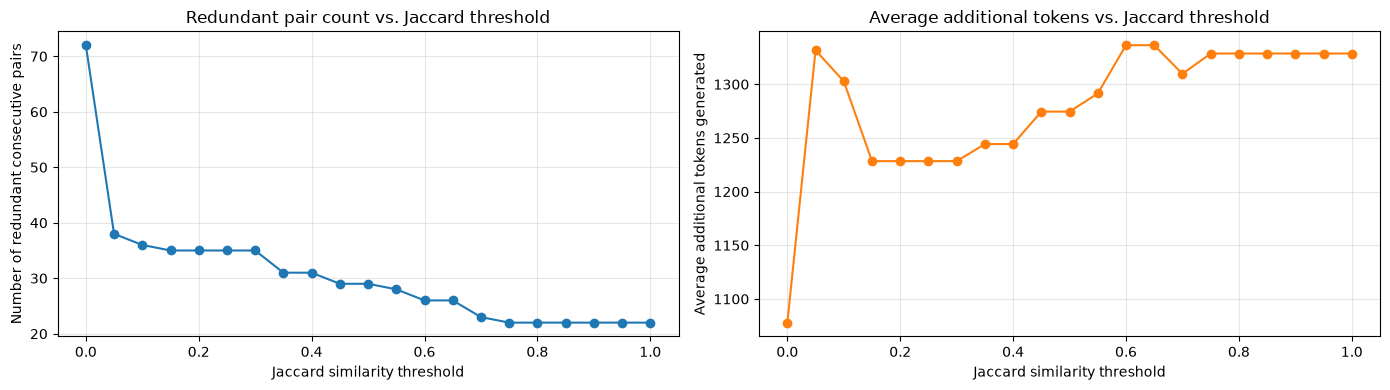

In [50]:
thresholds = [i / 20 for i in range(21)]
threshold_counts = []
avg_additional_tokens = []

for t in thresholds:
    threshold_findings = find_redundant_pairs(trajectories, threshold=t)
    threshold_counts.append(len(threshold_findings))

    token_values = [
        finding.get("tokens_extra")
        for finding in threshold_findings
        if finding.get("tokens_extra") is not None
    ]
    avg_additional_tokens.append(
        sum(token_values) / len(token_values) if token_values else None
    )

# Compute total number of possible consecutive step pairs across all trajectories
total_possible_pairs = sum(max(0, len(traj["steps"]) - 1) for traj in trajectories)

pair_ratios = [count / total_possible_pairs for count in threshold_counts]
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "pair_count": threshold_counts,
    "ratio": pair_ratios,
    "avg_additional_tokens_generated": avg_additional_tokens,
})

display(threshold_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(threshold_df["threshold"], threshold_df["pair_count"], marker="o")
axes[0].set_xlabel("Jaccard similarity threshold")
axes[0].set_ylabel("Number of redundant consecutive pairs")
axes[0].set_title("Redundant pair count vs. Jaccard threshold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(threshold_df["threshold"], threshold_df["avg_additional_tokens_generated"], marker="o", color="tab:orange")
axes[1].set_xlabel("Jaccard similarity threshold")
axes[1].set_ylabel("Average additional tokens generated")
axes[1].set_title("Average additional tokens vs. Jaccard threshold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()